In [ ]:
# Imports & Configuration
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Use GPU on Mac
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on: {device}")

Training on: mps


In [ ]:
# Load and Process
# Load your balanced real-world data
df = pd.read_csv('data/final_training_data.csv')
X = df.drop(columns=['Label']).values
y = df['Label'].values

# StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


os.makedirs('../controller/models_dist', exist_ok=True)
# Save the scaler where the Controller looks for it
joblib.dump(scaler, '../controller/models_dist/scaler.pkl')
print("✅ Scaler saved to ../controller/models_dist/scaler.pkl")

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Convert to Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device).unsqueeze(1)

print(f"Training Samples: {len(X_train)} | Testing Samples: {len(X_test)}")

✅ Scaler saved to ../controller/models_dist/scaler.pkl
Training Samples: 24441 | Testing Samples: 6111


In [ ]:
# Define Deep Dense Network (DNN)
class KRRAD_DNN(nn.Module):
    def __init__(self, input_dim):
        super(KRRAD_DNN, self).__init__()
        
        self.layer1 = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),  # Stabilizes learning
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2)       # Prevents overfitting
        )
        
        self.layer2 = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2)
        )
        
        self.layer3 = nn.Sequential(
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1)
        )
        
        self.output = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.output(x)
        return self.sigmoid(x)

model = KRRAD_DNN(input_dim=X_train.shape[1]).to(device)
print(model)

KRRAD_DNN(
  (layer1): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Dropout(p=0.2, inplace=False)
  )
  (layer2): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Dropout(p=0.2, inplace=False)
  )
  (layer3): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
  )
  (output): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [ ]:
# Training Loop with Live Validation
EPOCHS = 200
LR = 0.01

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Lists to store metrics for BOTH sets
history_train_loss = []
history_train_acc = []
history_val_loss = []
history_val_acc = []

print("🚀 Starting Training Session with Validation...")

for epoch in range(EPOCHS):
    # TRAIN MODE
    model.train()
    optimizer.zero_grad()
    
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    loss.backward()
    optimizer.step()
    
    # Calculate Training Metrics
    with torch.no_grad():
        train_preds = (outputs > 0.5).float()
        train_acc = (train_preds == y_train_tensor).float().mean()
        
    # VALIDATION MODE
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor)
        val_preds = (val_outputs > 0.5).float()
        val_acc = (val_preds == y_test_tensor).float().mean()
    
    # Save metrics
    history_train_loss.append(loss.item())
    history_train_acc.append(train_acc.item())
    history_val_loss.append(val_loss.item())
    history_val_acc.append(val_acc.item())
    
    # Step the scheduler based on Validation Loss (Smarter!)
    scheduler.step(val_loss)
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f} | Val Acc: {val_acc.item():.4f}")

print("✅ Training Complete.")

🚀 Starting Training Session with Validation...
Epoch [10/200] | Train Loss: 0.3773 | Val Loss: 0.3809 | Val Acc: 0.8877
Epoch [20/200] | Train Loss: 0.3385 | Val Loss: 0.3170 | Val Acc: 0.8902
Epoch [30/200] | Train Loss: 0.3090 | Val Loss: 0.2856 | Val Acc: 0.8895
Epoch [40/200] | Train Loss: 0.2693 | Val Loss: 0.2416 | Val Acc: 0.8959
Epoch [50/200] | Train Loss: 0.2402 | Val Loss: 0.2105 | Val Acc: 0.9030
Epoch [60/200] | Train Loss: 0.2158 | Val Loss: 0.2181 | Val Acc: 0.9036
Epoch [70/200] | Train Loss: 0.2028 | Val Loss: 0.1885 | Val Acc: 0.9049
Epoch [80/200] | Train Loss: 0.1909 | Val Loss: 0.1746 | Val Acc: 0.9206
Epoch [90/200] | Train Loss: 0.1828 | Val Loss: 0.1628 | Val Acc: 0.9323
Epoch [100/200] | Train Loss: 0.1841 | Val Loss: 0.1575 | Val Acc: 0.9324
Epoch [110/200] | Train Loss: 0.1747 | Val Loss: 0.1530 | Val Acc: 0.9370
Epoch [120/200] | Train Loss: 0.1684 | Val Loss: 0.1495 | Val Acc: 0.9444
Epoch [130/200] | Train Loss: 0.1681 | Val Loss: 0.1614 | Val Acc: 0.9341


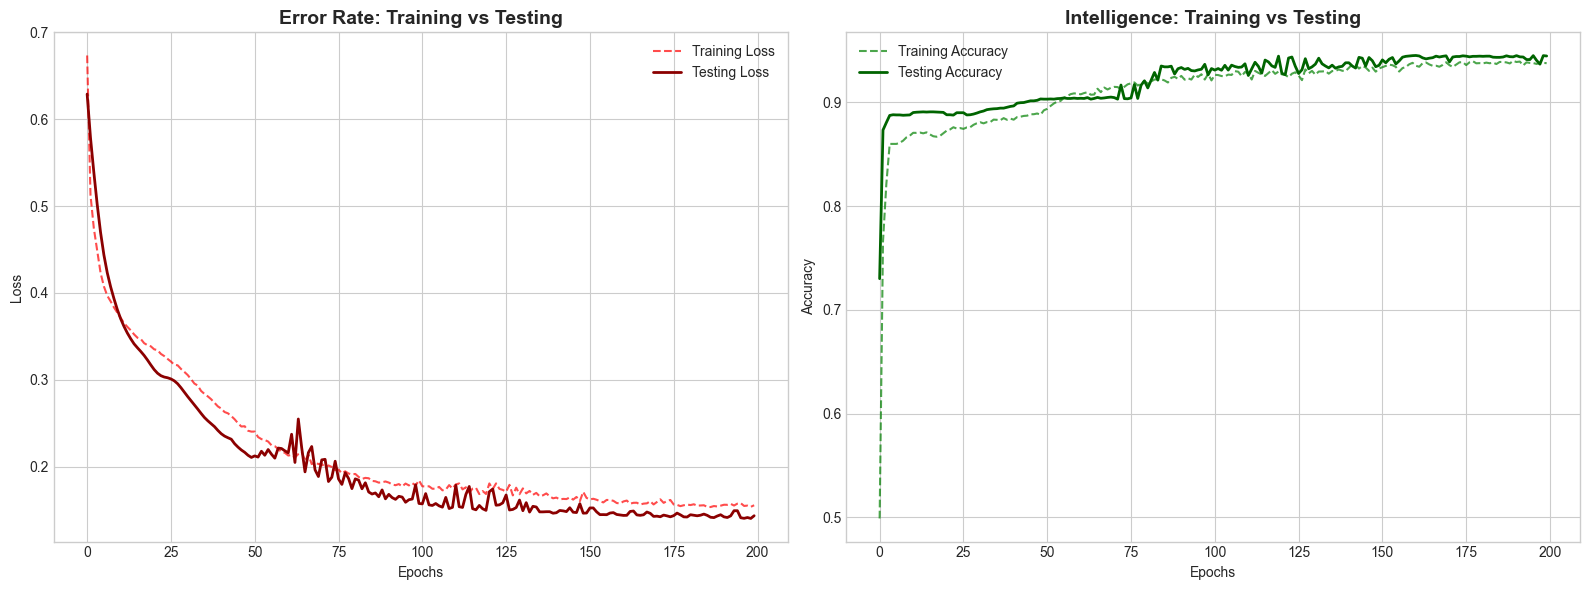

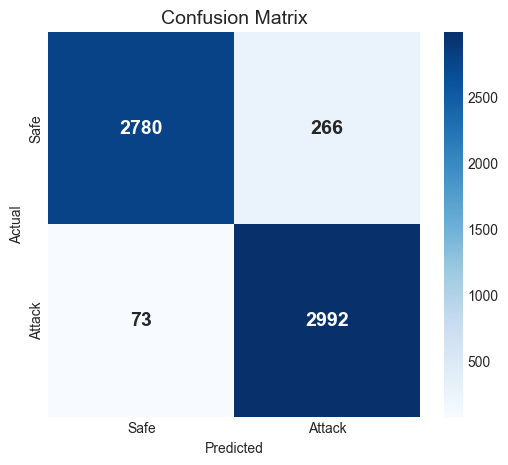

In [ ]:
# Advanced Visualization (Train vs Test)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(16, 6))

# Loss Comparison
plt.subplot(1, 2, 1)
plt.plot(history_train_loss, label='Training Loss', color='red', linestyle='--', alpha=0.7)
plt.plot(history_val_loss, label='Testing Loss', color='darkred', linewidth=2)
plt.title('Error Rate: Training vs Testing', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Comparison
plt.subplot(1, 2, 2)
plt.plot(history_train_acc, label='Training Accuracy', color='green', linestyle='--', alpha=0.7)
plt.plot(history_val_acc, label='Testing Accuracy', color='darkgreen', linewidth=2)
plt.title('Intelligence: Training vs Testing', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Confusion Matrix
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_preds = (test_outputs > 0.5).float()

cm = confusion_matrix(y_test, test_preds.cpu())

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Safe', 'Attack'], 
            yticklabels=['Safe', 'Attack'],
            annot_kws={"size": 14, "weight": "bold"})
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
# Final Report Card (Train vs Test)
from sklearn.metrics import accuracy_score

model.eval()

# Check Training Accuracy
with torch.no_grad():
    train_outputs = model(X_train_tensor)
    train_preds = (train_outputs > 0.5).float()
    # y_train_tensor is a Tensor, so .cpu() is needed
    train_acc = accuracy_score(y_train_tensor.cpu(), train_preds.cpu())

# Check Testing Accuracy
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_preds = (test_outputs > 0.5).float()
    # FIX: y_test is already Numpy, so NO .cpu() needed here
    test_acc = accuracy_score(y_test, test_preds.cpu())

print(f"📘 Training Accuracy: {train_acc*100:.2f}%")
print(f"📗 Testing Accuracy:  {test_acc*100:.2f}%")

if train_acc - test_acc > 0.05:
    print("⚠️ Warning: Model is Overfitting (Memorizing data).")
else:
    print("✅ Success: Model is Generalizing well (True Intelligence).")

📘 Training Accuracy: 94.47%
📗 Testing Accuracy:  94.45%
✅ Success: Model is Generalizing well (True Intelligence).


In [ ]:
# Save Model for Production
torch.save(model.state_dict(), "../controller/models_dist/dnn_model.pth")
print("✅ DNN Model saved to ../controller/models_dist/dnn_model.pth")

✅ DNN Model saved to ../controller/models_dist/dnn_model.pth
